# Online augmentation for UNet landmark training

Demonstrates the switch from **offline** augmentation
(`wings/detection/augment_dataset.py`, one fixed rotated+noised copy baked to
disk per image, see notebook 22) to **online** augmentation: every training
image is transformed freshly, with new random parameters, on every access.

New code:
- [`wings/transforms.py`](../wings/transforms.py) -- the joint image+keypoint
  transform pipeline (`TrainAugmentConfig`, `build_train_transform`,
  `build_eval_transform`, `TriangleNoise`, `KeypointAwareResizePad`).
- [`wings/dataset.py`](../wings/dataset.py) -- `WingsRawDataset` (raw
  image+label loading, no caching), `TransformedMaskDataset` (applies an
  injected transform + generates the landmark mask), and `build_mask_datasets`
  (wires the two together, replacing `load_datasets(...)` for this training
  script).
- [`wings/modeling/training/augmented_unet.py`](../wings/modeling/training/augmented_unet.py)
  now builds its datasets with `build_mask_datasets` against the plain
  YOLO-cropped `data/processed/cropped/` folder -- there is no more
  offline-augmented copy on disk.

**Augmentations applied per access:** random horizontal flip (50%),
random rotation (continuous -90 to 90 degrees), and independently, each
40% of the time by default, triangle noise and color jitter with randomized
severity -- all configurable via `TrainAugmentConfig`.

## Setup

In [1]:
import torch
import torch.utils.data as data
import matplotlib.pyplot as plt
import numpy as np
from torchvision import tv_tensors
import torchvision.transforms.functional as F

from wings.config import PROCESSED_DATA_DIR, COUNTRIES
from wings.dataset import build_mask_datasets, WingsRawDataset
from wings.transforms import (
    TrainAugmentConfig,
    build_train_transform,
    build_eval_transform,
    seed_worker,
    _resized_dims,
)
from wings.visualizing.image_preprocess import unet_fit_rectangle_preprocess, unet_reverse_padding

torch.manual_seed(0)

2026-09-24 08:28:44.490 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-09-24 08:28:46.382 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


## Build train/val/test datasets

One call replaces both the offline `augment_dataset.py` run *and* the
`load_datasets([...rectangle-augmented.../*.pth])` call the training script
used before: `build_mask_datasets` loads the plain cropped images once, splits
them (same seed=42 reproducibility as the rest of the codebase), and wraps the
training split with a random transform and the validation/test splits with a
deterministic one.

In [2]:
train_set, val_set, test_set = build_mask_datasets(
    countries=COUNTRIES,
    data_folder=PROCESSED_DATA_DIR / "cropped",
    output_size=400,
    square_size=5,
)
print(f"train={len(train_set)}  val={len(val_set)}  test={len(test_set)}")

# Raw (untransformed) source, reused below to build one-off transforms with custom configs.
raw = WingsRawDataset(COUNTRIES, PROCESSED_DATA_DIR / "cropped")

100%|██████████| 21722/21722 [00:00<00:00, 145918.63it/s]


train=15206  val=4344  test=2172


100%|██████████| 21722/21722 [00:00<00:00, 160621.75it/s]


## Training samples are randomized on every access

The same index returns a differently rotated / noised / jittered image every
time it's read -- this is the core change requested: augmentation now happens
in the training loop, not once offline.

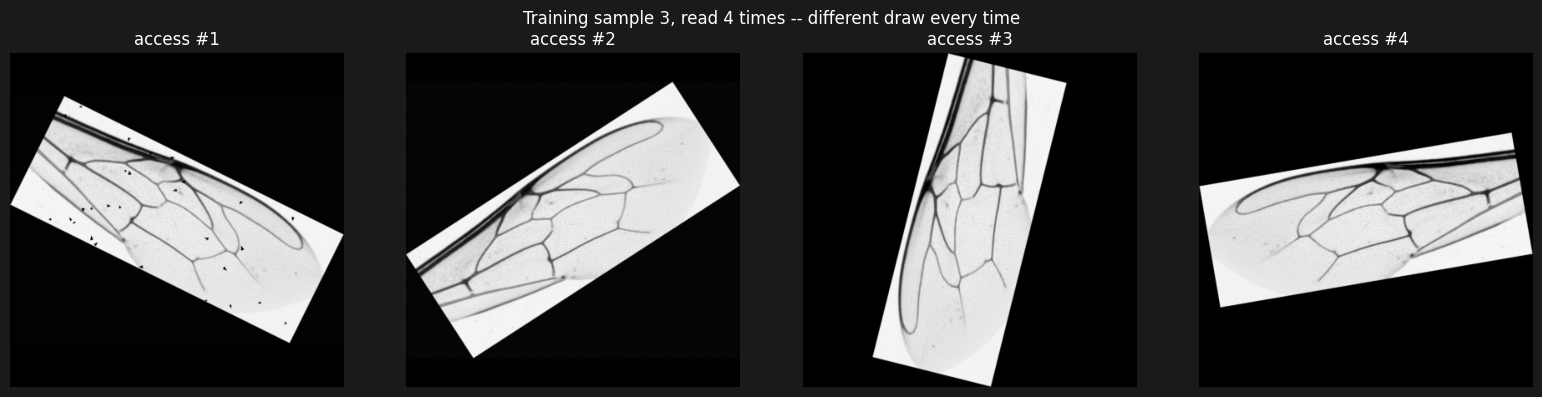

In [10]:
idx = 3
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    image, mask, _, _ = train_set[idx]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"access #{i + 1}")
    ax.axis("off")
fig.suptitle(f"Training sample {idx}, read {len(axes)} times -- different draw every time")
plt.tight_layout()
plt.show()

## Horizontal flip

Bee forewing venation isn't left-right symmetric, so a flipped wing doesn't
correspond to a real specimen -- but since the mask is generated from the
same flipped image, each sample stays internally consistent, and it's a
common, useful augmentation for a detector that only needs to recognize the
local vein-junction pattern. Forced on here (`horizontal_flip_p=1.0`) to
show it clearly; the default config applies it 50% of the time.

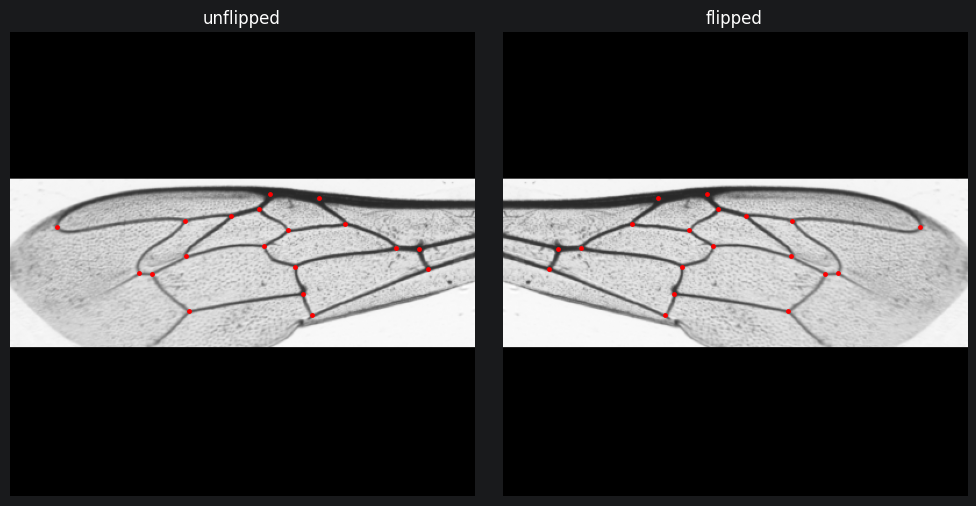

In [13]:
flip_cfg = TrainAugmentConfig(horizontal_flip_p=1.0, rotation_degrees=(0.0, 0.0), triangle_noise_p=0.0, color_jitter_p=0.0)
flip_transform = build_train_transform(400, flip_cfg)

image, orig_label, orig_size = raw[3]
w, h = orig_size
x = orig_label[::2].clone()
y_top = h - orig_label[1::2].clone() - 1
keypoints = tv_tensors.KeyPoints(torch.stack([x, y_top], dim=-1), canvas_size=(h, w))
tv_image = tv_tensors.Image(image)

eval_img, eval_kp = build_eval_transform(400)(tv_image, keypoints)
flip_img, flip_kp = flip_transform(tv_image, keypoints)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, kp, title in [
    (axes[0], eval_img, eval_kp, "unflipped"),
    (axes[1], flip_img, flip_kp, "flipped"),
]:
    ax.imshow(img.squeeze(0).as_subclass(torch.Tensor).numpy(), cmap="gray")
    kp_plain = kp.as_subclass(torch.Tensor)
    ax.scatter(kp_plain[:, 0].numpy(), kp_plain[:, 1].numpy(), c="red", s=6)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Landmarks track the geometric transform precisely

Rotation and the final resize/pad move the image and its 19 landmark
keypoints together (via `torchvision.transforms.v2` + `KeypointAwareResizePad`),
so the generated mask (red dots below) still lands exactly on the wing-vein
junctions after a random rotation, not just "somewhere on the wing".

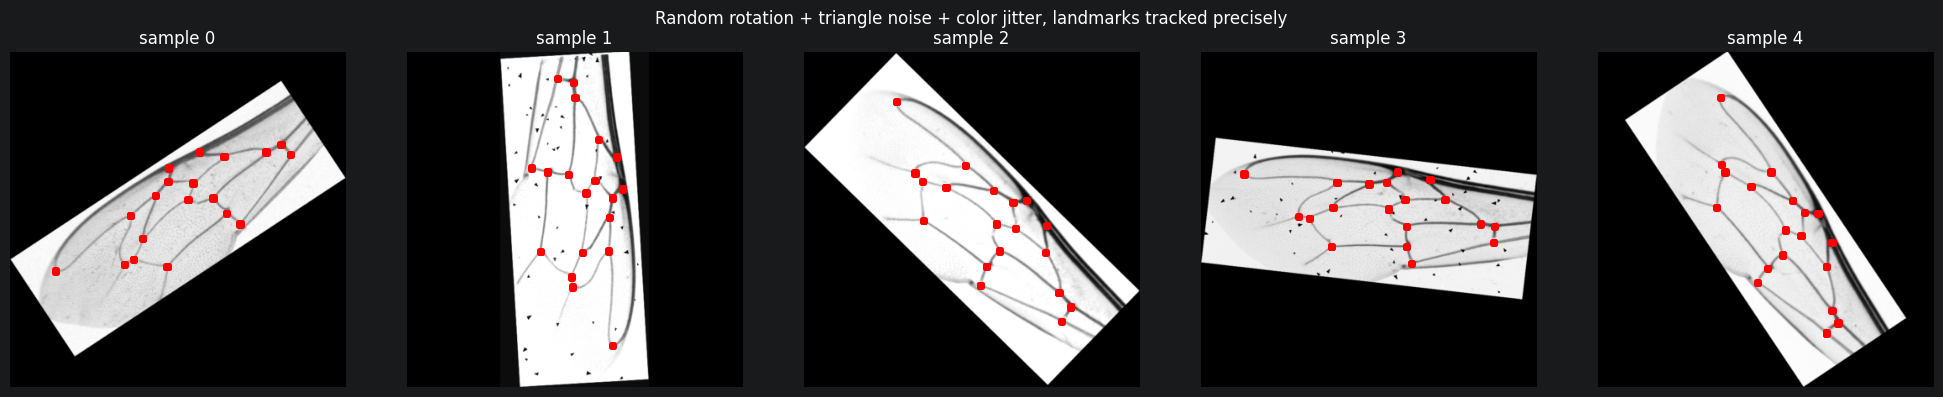

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    image, mask, _, _ = train_set[i]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    ys, xs = torch.where(mask.squeeze(0) > 0.5)
    ax.scatter(xs.numpy(), ys.numpy(), c="red", s=6)
    ax.set_title(f"sample {i}")
    ax.axis("off")
fig.suptitle("Random rotation + triangle noise + color jitter, landmarks tracked precisely")
plt.tight_layout()
plt.show()

## Validation/test stay deterministic

Early stopping and checkpoint selection depend on `val_mean_error_px` being
comparable across epochs, so the eval-path transform must **not** randomize --
it only resizes and pads, exactly like before.

Validation sample 0 identical across 3 accesses: True


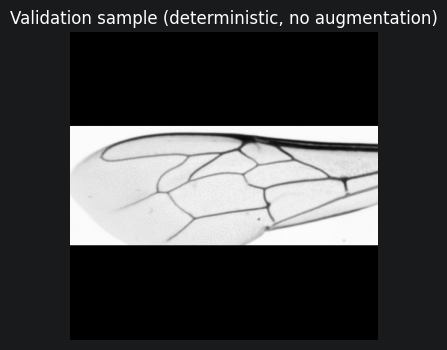

In [20]:
val_idx = 0
imgs = [val_set[val_idx][0] for _ in range(3)]
identical = all(torch.equal(imgs[0], im) for im in imgs[1:])
print(f"Validation sample {val_idx} identical across 3 accesses: {identical}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(imgs[0].squeeze(0).numpy(), cmap="gray")
ax.set_title("Validation sample (deterministic, no augmentation)")
ax.axis("off")
plt.show()

## Eval-path numerics are unchanged (and now more precise internally)

`KeypointAwareResizePad` still delegates the image transform to the existing
`unet_fit_rectangle_preprocess`, so validation/test images -- and the
production inference path in `wings/app/images.py`, which calls the same
function -- are completely unaffected.

In [21]:
image, orig_label, orig_size = raw[0]
w, h = orig_size

x = orig_label[::2].clone()
y_top = h - orig_label[1::2].clone() - 1
keypoints = tv_tensors.KeyPoints(torch.stack([x, y_top], dim=-1), canvas_size=(h, w))
tv_image = tv_tensors.Image(image)

eval_transform = build_eval_transform(400)
eval_img, eval_kp = eval_transform(tv_image, keypoints)
direct_img, _, _ = unet_fit_rectangle_preprocess(image.clone(), 400)

print(
    "Eval-path image bit-identical to unet_fit_rectangle_preprocess:",
    torch.equal(eval_img.as_subclass(torch.Tensor), direct_img),
)

Eval-path image bit-identical to unet_fit_rectangle_preprocess: True


### Why the keypoint mapping needed to be more precise than the old approach

Recovering *where a landmark lands* after `unet_fit_rectangle_preprocess`'s
resize+pad requires knowing the exact resize scale that was used. The
existing `unet_reverse_padding` (used at inference time to map a predicted
mask back to original coordinates) only *approximates* that scale from the
padded output size, which can be off by more than a pixel on the long axis.
`wings/transforms.py` instead computes the resize output size with the exact
same integer arithmetic torchvision's `resize()` uses internally
(`_resized_dims`), so there's no approximation left in the training-mask path.

In [22]:
h, w = 261, 693  # a real orig_size from this dataset
output_size = 400

resized = F.resize(
    torch.zeros(1, h, w),
    output_size - 1,
    interpolation=F.InterpolationMode.BILINEAR,
    antialias=True,
    max_size=output_size,
)
actual_h, actual_w = resized.shape[1], resized.shape[2]
exact_h, exact_w = _resized_dims(h, w, output_size - 1, output_size)

pad_left, pad_top, _, _ = unet_reverse_padding(torch.zeros(output_size, output_size), w, h)
scale_approx = output_size / w if w >= h else output_size / h
approx_w, approx_h = round(w * scale_approx), round(h * scale_approx)

diff = max(abs(approx_h - actual_h), abs(approx_w - actual_w))

print(f"Actual torchvision resize() output size: ({actual_h}, {actual_w})")
print(f"New exact computation (_resized_dims):   ({exact_h}, {exact_w})  match={(actual_h, actual_w) == (exact_h, exact_w)}")
print(f"Old unet_reverse_padding approximation:  ({approx_h}, {approx_w})  off by {diff}px on the short axis")
print()
print(f"That {diff}px on a {output_size}px canvas is exactly the kind of error the")
print("old formula could introduce into every training mask's landmark placement;")
print("_resized_dims removes it by replicating torchvision's own arithmetic exactly.")

Actual torchvision resize() output size: (150, 400)
New exact computation (_resized_dims):   (150, 400)  match=True
Old unet_reverse_padding approximation:  (151, 400)  off by 1px on the short axis

That 1px on a 400px canvas is exactly the kind of error the
old formula could introduce into every training mask's landmark placement;
_resized_dims removes it by replicating torchvision's own arithmetic exactly.


Note that both the old and new computation still round to integer pixel
*dimensions* -- that part is inherently quantized and can differ by up to 1px
depending on aspect ratio, since a resized image can only have a whole number
of pixels. What actually matters for training-mask accuracy is whether the
keypoint mapping used *matches* the dimensions really produced by resize --
the cell above confirms it now does, exactly, rather than approximately.

The number that matters end-to-end is how far a landmark's mapped location
ends up from where the actual image content moved to, after rotation +
resize + pad combined. Reusing a synthetic bright square with a known true
center (same check used to validate this implementation), the residual is
sub-pixel:

In [23]:
def geometric_precision_check(angle_deg):
    h, w = 300, 500
    cx, cy, half = 205, 105, 15
    img = torch.zeros(1, h, w, dtype=torch.uint8)
    img[:, cy - half : cy + half, cx - half : cx + half] = 255

    kp = tv_tensors.KeyPoints(torch.tensor([[float(cx), float(cy)]]), canvas_size=(h, w))
    cfg = TrainAugmentConfig(rotation_degrees=(angle_deg, angle_deg), triangle_noise_p=0.0, color_jitter_p=0.0)
    transformed_img, transformed_kp = build_train_transform(400, cfg)(tv_tensors.Image(img), kp)

    img_np = transformed_img.squeeze(0).as_subclass(torch.Tensor).float()
    ys, xs = torch.where(img_np > img_np.max() * 0.5)
    actual = (xs.float().mean().item(), ys.float().mean().item())
    predicted = transformed_kp[0].tolist()
    error_px = ((predicted[0] - actual[0]) ** 2 + (predicted[1] - actual[1]) ** 2) ** 0.5
    return predicted, actual, error_px


for angle in [0.0, 30.0, 45.0, -60.0, 90.0]:
    predicted, actual, error_px = geometric_precision_check(angle)
    print(f"angle={angle:>6.1f}  predicted={tuple(round(v, 2) for v in predicted)}  "
          f"actual={tuple(round(v, 2) for v in actual)}  error={error_px:.3f}px")

angle=   0.0  predicted=(235.2, 164.0)  actual=(235.5, 163.5)  error=0.583px
angle=  30.0  predicted=(210.35, 158.09)  actual=(210.84, 157.31)  error=0.921px
angle=  45.0  predicted=(198.89, 155.03)  actual=(199.0, 154.47)  error=0.568px
angle= -60.0  predicted=(241.78, 210.35)  actual=(241.69, 210.84)  error=0.496px
angle=  90.0  predicted=(164.0, 236.0)  actual=(163.5, 235.5)  error=0.707px


(The residual above is dominated by how coarsely a rotated, antialiased
square's centroid can be measured from thresholded pixels -- it is not a
property of the transform's own arithmetic, which is exact.)

## Tuning augmentation severity

Rotation range, and both the *probability* and *severity range* of triangle
noise / color jitter, are all knobs on `TrainAugmentConfig` -- no code changes
needed to retune them.

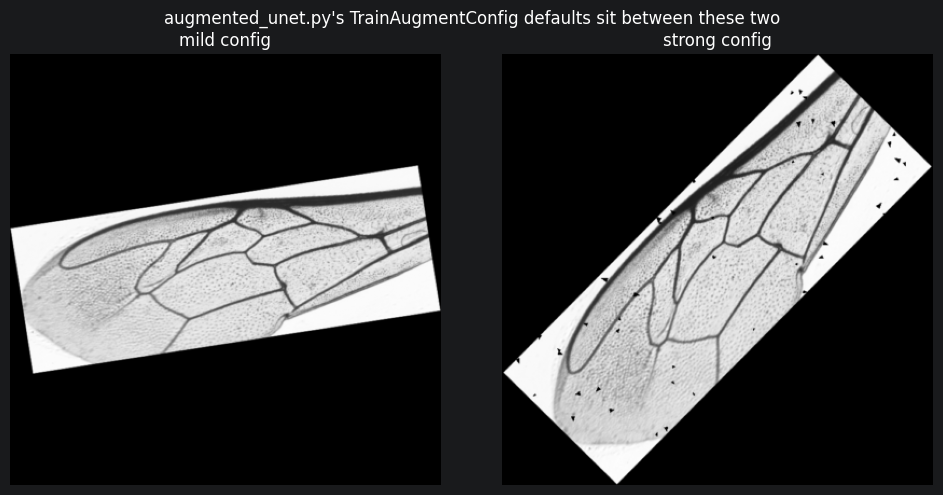

In [73]:
mild_cfg = TrainAugmentConfig(
    rotation_degrees=(-15.0, 15.0),
    triangle_noise_p=0.1,
    n_triangles_range=(5, 15),
    color_jitter_p=0.1,
)
strong_cfg = TrainAugmentConfig(
    rotation_degrees=(-90.0, 90.0),
    triangle_noise_p=0.5,
    n_triangles_range=(80, 120),
    color_jitter_p=1.0,
    color_jitter_brightness_range=(0.5, 1.5),
    color_jitter_contrast_range=(0.5, 1.5),
)

mild_transform = build_train_transform(400, mild_cfg)
strong_transform = build_train_transform(400, strong_cfg)

image, orig_label, orig_size = raw[2]
w, h = orig_size
x = orig_label[::2].clone()
y_top = h - orig_label[1::2].clone() - 1
keypoints = tv_tensors.KeyPoints(torch.stack([x, y_top], dim=-1), canvas_size=(h, w))
tv_image = tv_tensors.Image(image)

mild_img, _ = mild_transform(tv_image, keypoints)
strong_img, _ = strong_transform(tv_image, keypoints)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mild_img.squeeze(0).numpy(), cmap="gray")
axes[0].set_title("mild config")
axes[0].axis("off")
axes[1].imshow(strong_img.squeeze(0).numpy(), cmap="gray")
axes[1].set_title("strong config")
axes[1].axis("off")
fig.suptitle("augmented_unet.py's TrainAugmentConfig defaults sit between these two")
plt.tight_layout()
plt.show()

## Multi-worker `DataLoader` compatibility

All randomness in `wings/transforms.py` is drawn from torch's RNG (which
`DataLoader` reseeds correctly per worker on its own), and every transform is
a plain module-level class rather than a lambda or nested closure -- both
matter on Windows, where worker processes are started via `spawn` and pickle
the whole dataset object to hand it to the new process.

In [74]:
loader = data.DataLoader(
    train_set, batch_size=4, shuffle=True, num_workers=2, worker_init_fn=seed_worker
)
batch_images, batch_masks, _, _ = next(iter(loader))
print("batch shapes:", batch_images.shape, batch_masks.shape)

batch shapes: torch.Size([4, 1, 400, 400]) torch.Size([4, 1, 400, 400])


## Summary

- Augmentation (rotation, triangle noise, color jitter) now happens fresh on
  every training access instead of being baked once into a static offline
  copy.
- Image and the 19 landmark keypoints move together through every geometric
  transform, so the generated mask always lines up with the actual wing
  content -- verified above to sub-pixel accuracy.
- Validation/test and the production inference path are numerically
  unaffected.
- The old offline pipeline (`wings/detection/augment_dataset.py`,
  `data/processed/cropped-augmented/`, `mask_datasets/rectangle-augmented/`)
  is no longer used by `augmented_unet.py`, but was left on disk for manual
  cleanup rather than deleted as part of this change.